# Large demo notebook

Larger integrated demo with generated data, writefile magic, shell commands, captured output, widgets, HTML display, timing, tables, and plots.

In [17]:
get_ipython().run_line_magic("matplotlib", "inline")


In [18]:
%cd .


c:\Users\dbran\OneDrive\FH\4. Semester\KIS\Jupyter2Marimo\demo


## Imports and configuration

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, HTML

report_title = "Operations Demo Report"
data_file = "large_demo_data.csv"
notes_file = "large_demo_notes.txt"
regions = ["north", "south", "east", "west"]
products = ["alpha", "beta", "gamma"]


In [20]:
%%writefile large_demo_notes.txt
Large demo notes
================
This text file was created by a Jupyter cell magic.


Writing large_demo_notes.txt


## Generate synthetic operations data

In [21]:
rows = []
for index in range(90):
    region = regions[index % len(regions)]
    product = products[index % len(products)]
    units = 20 + (index * 5) % 60
    revenue = units * (8 + index % 5)
    cost = units * (4 + index % 3)
    rows.append({
        "id": index + 1,
        "region": region,
        "product": product,
        "units": units,
        "revenue": revenue,
        "cost": cost,
    })

raw = pd.DataFrame(rows)
raw["profit"] = raw["revenue"] - raw["cost"]
raw.to_csv(data_file, index=False)
display(raw.head())


,id,region,product,units,revenue,cost,profit
0,1,north,alpha,20,160,80,80
1,2,south,beta,25,225,125,100
2,3,east,gamma,30,300,180,120
3,4,west,alpha,35,385,140,245
4,5,north,beta,40,480,200,280


## Inspect generated files

In [22]:
generated_files = sorted(path.name for path in Path(".").iterdir())
print(generated_files)


['large_demo.ipynb', 'large_demo_data.csv', 'large_demo_notes.txt', 'medium_demo.ipynb', 'medium_sales.csv', 'small_demo.ipynb', 'tiny_basic_demo.ipynb']


In [23]:
print(Path(notes_file).read_text(encoding="utf-8"))


Large demo notes
This text file was created by a Jupyter cell magic.



In [24]:
csv_files = sorted(path.name for path in Path(".").glob("*.csv"))
print("csv files:", csv_files)


csv files: ['large_demo_data.csv', 'medium_sales.csv']


## Load and filter

In [25]:
data = pd.read_csv(data_file)
notes = Path(notes_file).read_text(encoding="utf-8")
print(notes)
display(data.head(8))


Large demo notes
This text file was created by a Jupyter cell magic.



,id,region,product,units,revenue,cost,profit
0,1,north,alpha,20,160,80,80
1,2,south,beta,25,225,125,100
2,3,east,gamma,30,300,180,120
3,4,west,alpha,35,385,140,245
4,5,north,beta,40,480,200,280
5,6,south,gamma,45,360,270,90
6,7,east,alpha,50,450,200,250
7,8,west,beta,55,550,275,275


In [26]:
region_widget = widgets.Dropdown(
    options=["all"] + sorted(data["region"].unique()),
    value="all",
    description="Region:",
)
min_profit_widget = widgets.IntSlider(
    value=100,
    min=0,
    max=500,
    step=25,
    description="Min profit:",
)

display(region_widget)
display(min_profit_widget)


Dropdown(description='Region:', options=('all', 'east', 'north', 'south', 'west'), value='all')

IntSlider(value=100, description='Min profit:', max=500, step=25)

In [27]:
filtered = data[data["profit"] >= min_profit_widget.value]
if region_widget.value != "all":
    filtered = filtered[filtered["region"] == region_widget.value]

summary = filtered.groupby("product")[["units", "revenue", "cost", "profit"]].mean()
display(summary)


,units,revenue,cost,profit
product,,,,
alpha,43.035714,434.285714,172.142857,262.142857
beta,48.035714,483.928571,240.178571,243.750000
gamma,54.600000,556.800000,327.600000,229.200000


In [28]:
%timeit filtered["profit"].sum()


12 μs ± 1.1 μs per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


In [29]:
%%time
total_revenue = filtered["revenue"].sum()
total_profit = filtered["profit"].sum()
print("total revenue:", total_revenue)
print("total profit:", total_profit)


total revenue: 39630
total profit: 19895
CPU times: total: 0 ns
Wall time: 1.15 ms


## Rich report

In [30]:
display(HTML(
    f"<h2>{report_title}</h2>"
    f"<p>Rows after filtering: <b>{len(filtered)}</b></p>"
    f"<p>Total revenue: <b>{total_revenue}</b></p>"
    f"<p>Total profit: <b>{total_profit}</b></p>"
))


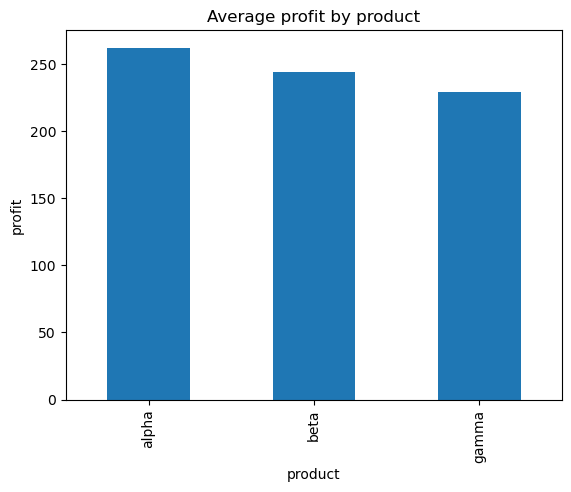

In [31]:
ax = summary["profit"].plot(kind="bar", title="Average profit by product")
ax.set_ylabel("profit")
plt.show()


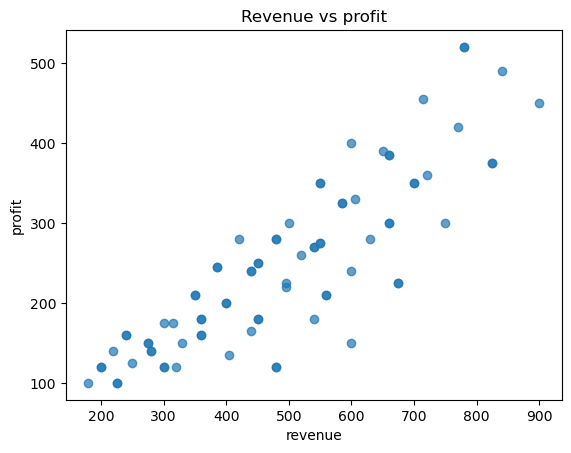

In [32]:
fig, ax = plt.subplots()
ax.scatter(filtered["revenue"], filtered["profit"], alpha=0.7)
ax.set_xlabel("revenue")
ax.set_ylabel("profit")
ax.set_title("Revenue vs profit")
plt.show()
